# 🔍 DefectVision — 01. Exploration du dataset MVTec AD

**Objectif** : Télécharger MVTec AD via Kaggle et explorer sa structure.

**Workflow** :
```
Kaggle API → Download → Google Drive → Exploration → Visualisation
```

## 0. Setup — Kaggle API

In [1]:
import os

# ⚠️ Remplace par tes credentials Kaggle
os.environ['KAGGLE_USERNAME'] = 'NaimMG'
os.environ['KAGGLE_KEY']      = 'KGAT_7505269a2e300d266d46b3457e655a16'

print('✅ Variables Kaggle configurées')

✅ Variables Kaggle configurées


In [2]:
!pip install -q kaggle Pillow matplotlib

## 1. Téléchargement MVTec AD

In [3]:
!kaggle datasets download -d ipythonx/mvtec-ad --path /content/mvtec_raw --unzip
print('✅ Dataset téléchargé')

Dataset URL: https://www.kaggle.com/datasets/ipythonx/mvtec-ad
License(s): copyright-authors
100% 4.90G/4.91G [00:46<00:00, 248MB/s]
100% 4.91G/4.91G [00:46<00:00, 114MB/s]
✅ Dataset téléchargé


In [4]:
import os

base_path  = '/content/mvtec_raw'
categories = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])

print(f'✅ {len(categories)} catégories trouvées :\n')
for i, cat in enumerate(categories):
    print(f'  {i+1:02d}. {cat}')

✅ 15 catégories trouvées :

  01. bottle
  02. cable
  03. capsule
  04. carpet
  05. grid
  06. hazelnut
  07. leather
  08. metal_nut
  09. pill
  10. screw
  11. tile
  12. toothbrush
  13. transistor
  14. wood
  15. zipper


## 2. Sauvegarde sur Google Drive

In [5]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/defect-vision/data/mvtec'
os.makedirs(DRIVE_PATH, exist_ok=True)
print(f'✅ Dossier Drive prêt : {DRIVE_PATH}')

Mounted at /content/drive
✅ Dossier Drive prêt : /content/drive/MyDrive/defect-vision/data/mvtec


In [6]:
import shutil

if not os.path.exists(os.path.join(DRIVE_PATH, 'bottle')):
    print('📦 Copie vers Drive en cours...')
    shutil.copytree(base_path, DRIVE_PATH, dirs_exist_ok=True)
    print('✅ Dataset sauvegardé sur Drive')
else:
    print('✅ Dataset déjà présent sur Drive — skip')

📦 Copie vers Drive en cours...
✅ Dataset sauvegardé sur Drive


## 3. Exploration — Structure bottle

In [7]:
from pathlib import Path

DATA_PATH = Path(DRIVE_PATH)
CATEGORY  = 'bottle'

train_good = list((DATA_PATH / CATEGORY / 'train' / 'good').glob('*.png'))
test_good  = list((DATA_PATH / CATEGORY / 'test'  / 'good').glob('*.png'))

test_defects = {}
for defect_dir in (DATA_PATH / CATEGORY / 'test').iterdir():
    if defect_dir.is_dir() and defect_dir.name != 'good':
        test_defects[defect_dir.name] = list(defect_dir.glob('*.png'))

print(f'=== Catégorie : {CATEGORY} ===')
print(f'  Train good   : {len(train_good)} images')
print(f'  Test good    : {len(test_good)} images')
print(f'  Test defects :')
total_defects = 0
for name, imgs in sorted(test_defects.items()):
    print(f'    - {name:20s} : {len(imgs)} images')
    total_defects += len(imgs)
print(f'  Total défauts: {total_defects} images')

=== Catégorie : bottle ===
  Train good   : 209 images
  Test good    : 20 images
  Test defects :
    - broken_large         : 20 images
    - broken_small         : 22 images
    - contamination        : 21 images
  Total défauts: 63 images


## 4. Distribution — toutes catégories

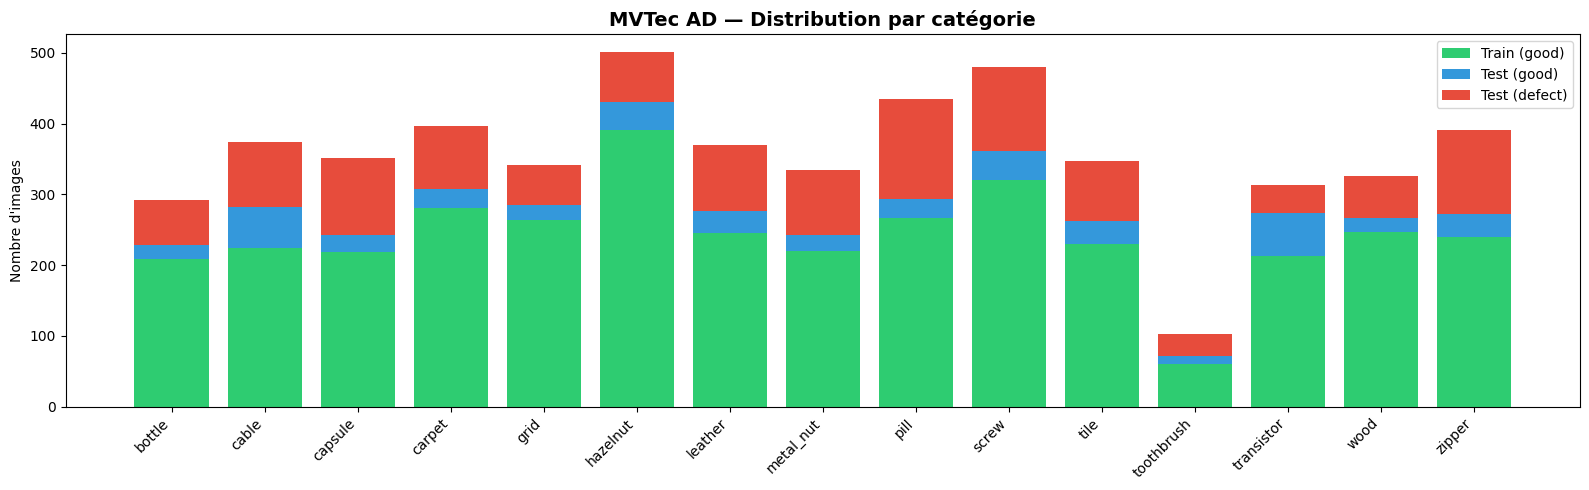

✅ Sauvegardé : mvtec_distribution.png


In [8]:
import matplotlib.pyplot as plt

summary = {}
for cat in categories:
    cat_path = DATA_PATH / cat
    n_train = len(list((cat_path / 'train' / 'good').glob('*.png')))
    n_test_good = len(list((cat_path / 'test' / 'good').glob('*.png')))
    n_test_defect = sum(
        len(list(d.glob('*.png')))
        for d in (cat_path / 'test').iterdir()
        if d.is_dir() and d.name != 'good'
    )
    summary[cat] = {'train': n_train, 'test_good': n_test_good, 'test_defect': n_test_defect}

cats   = list(summary.keys())
trains = [summary[c]['train'] for c in cats]
tgood  = [summary[c]['test_good'] for c in cats]
tdef   = [summary[c]['test_defect'] for c in cats]

x = range(len(cats))
fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x, trains, label='Train (good)',   color='#2ecc71')
ax.bar(x, tgood,  bottom=trains,          label='Test (good)',   color='#3498db')
ax.bar(x, tdef,   bottom=[t+g for t,g in zip(trains,tgood)], label='Test (defect)', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(cats, rotation=45, ha='right')
ax.set_title('MVTec AD — Distribution par catégorie', fontsize=14, fontweight='bold')
ax.set_ylabel("Nombre d'images")
ax.legend()
plt.tight_layout()
plt.savefig('mvtec_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sauvegardé : mvtec_distribution.png')

## 5. Visualisation — Good vs Defect

/tmp/ipykernel_573/212621734.py:21: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_573/212621734.py:21: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_573/212621734.py:22: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('samples_bottle.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_573/212621734.py:22: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('samples_bottle.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.c

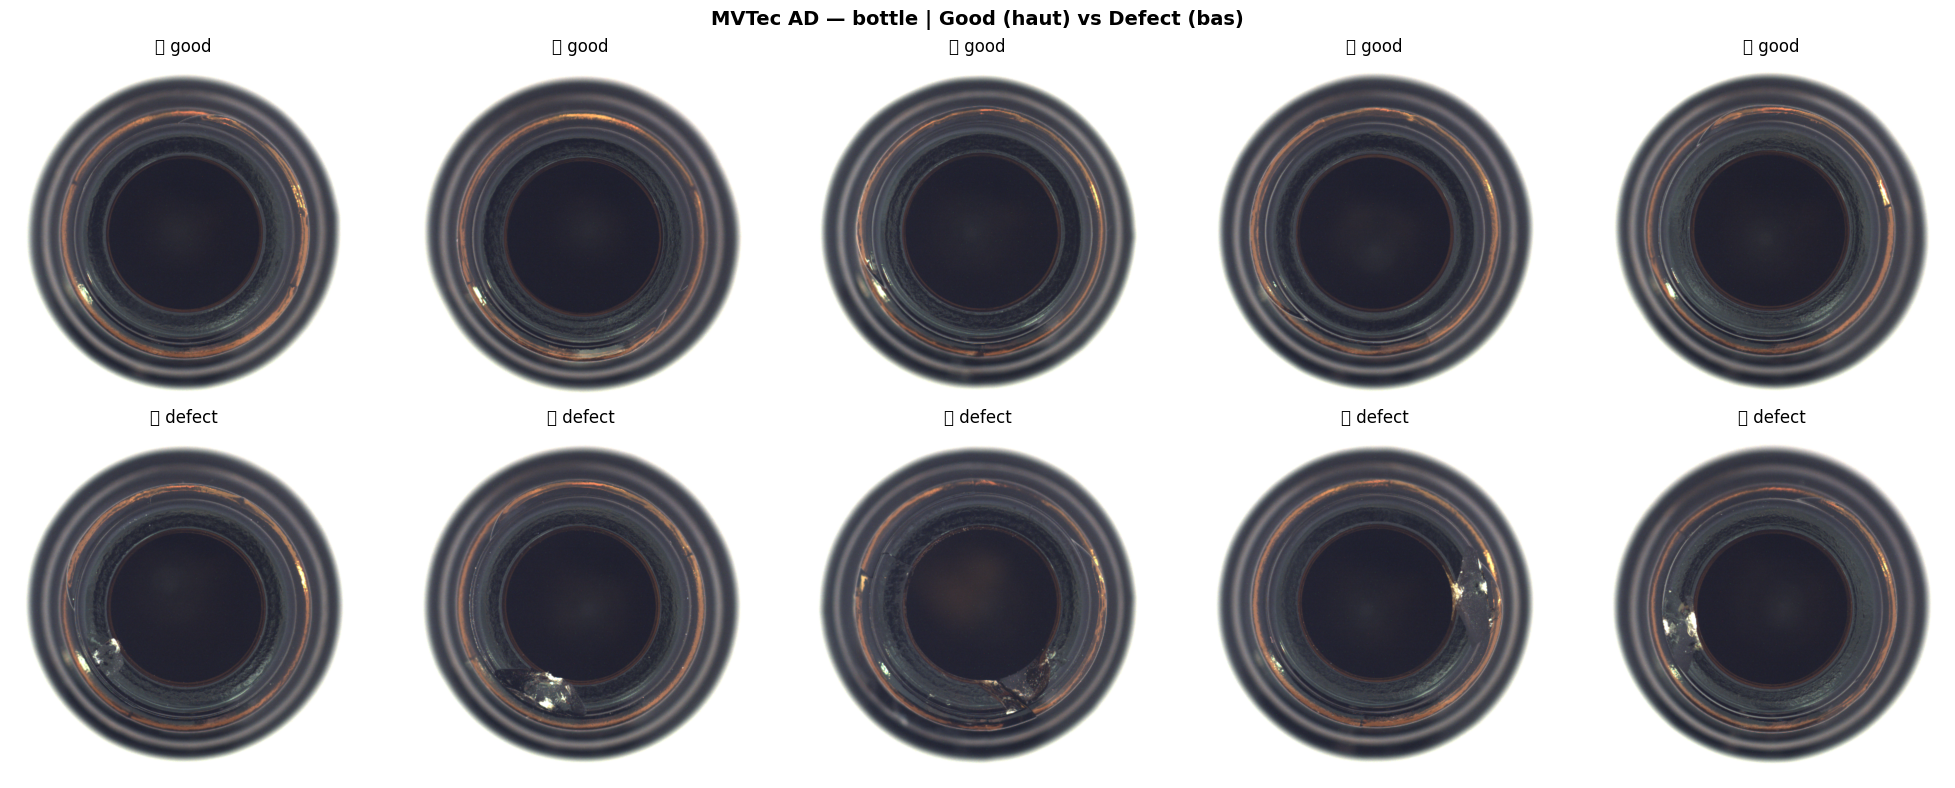

In [9]:
from PIL import Image
import random

good_samples   = random.sample(train_good, 5)
first_defects  = list(test_defects.values())[0]
defect_samples = random.sample(first_defects, min(5, len(first_defects)))

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle(f'MVTec AD — {CATEGORY} | Good (haut) vs Defect (bas)', fontsize=14, fontweight='bold')

for i in range(5):
    axes[0, i].imshow(Image.open(good_samples[i]))
    axes[0, i].set_title('✅ good')
    axes[0, i].axis('off')

for i in range(len(defect_samples)):
    axes[1, i].imshow(Image.open(defect_samples[i]))
    axes[1, i].set_title('❌ defect')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('samples_bottle.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Statistiques images

In [10]:
import numpy as np

sizes   = [Image.open(p).size for p in train_good]
widths  = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

print('=== Statistiques images — bottle/train ===')
print(f'  Largeur  — min: {min(widths)}  max: {max(widths)}  mean: {np.mean(widths):.0f}')
print(f'  Hauteur  — min: {min(heights)} max: {max(heights)} mean: {np.mean(heights):.0f}')
print(f'  Taille unique : {len(set(sizes)) == 1}')
if len(set(sizes)) == 1:
    print(f'  → Toutes les images font {sizes[0][0]}x{sizes[0][1]} px')

=== Statistiques images — bottle/train ===
  Largeur  — min: 900  max: 900  mean: 900
  Hauteur  — min: 900 max: 900 mean: 900
  Taille unique : True
  → Toutes les images font 900x900 px


## ✅ Résumé

| Info | Valeur |
|------|--------|
| Dataset | MVTec AD (via Kaggle) |
| Stockage | Google Drive `/defect-vision/data/mvtec` |
| Catégories | 15 |
| Prochain notebook | `02_yolov8_training.ipynb` |

**Prochaine étape** : Préparer les données au format YOLO et entraîner YOLOv8 sur `bottle`.